<a href="https://colab.research.google.com/github/Aauia/Web-Dev/blob/main/McDonaldReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap

# Torch ML libraries
import transformers
from transformers import BertModel, BertTokenizer, AdamW, get_linear_schedule_with_warmup
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader

# Misc.
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Set intial variables and constants
%config InlineBackend.figure_format='retina'

# Graph Designs
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))
rcParams['figure.figsize'] = 12, 8

# Random seed for reproducibilty
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Set GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
file_path = "/content/sample_data/McDonalds-Yelp-Sentiment-DFE.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1", on_bad_lines="skip", delimiter=";")
print(df.head())  # Check if columns are properly separated now


    _unit_id policies_violated  stars     city  \
0  679455654       RudeService      1  Atlanta   
1  679455655       SlowService      5  Atlanta   
2  679455656                na      1  Atlanta   
3  679455657       RudeService      2  Atlanta   
4  679455658           BadFood      4  Atlanta   

                                              review  
0  Terrible customer service. Î¾I came in at 9:30...  
1                                                NaN  
2  I see I'm not the only one giving 1 star. Only...  
3  Well, it's McDonald's, so you know what the fo...  
4                                                NaN  


In [ ]:
df.isnull().sum()
print(df.get('stars'))  # If None, column is missing


0      1
1      5
2      1
3      2
4      4
      ..
198    3
199    5
200    5
201    2
202    2
Name: stars, Length: 203, dtype: int64


In [ ]:
# Function to convert score to sentiment
def to_sentiment(rating):

    rating = int(rating)

    # Convert to class
    if rating <= 2:
        return 0
    elif rating == 3:
        return 1
    else:
        return 2

# Apply to the dataset
df['sentiment'] = df.stars.apply(to_sentiment)

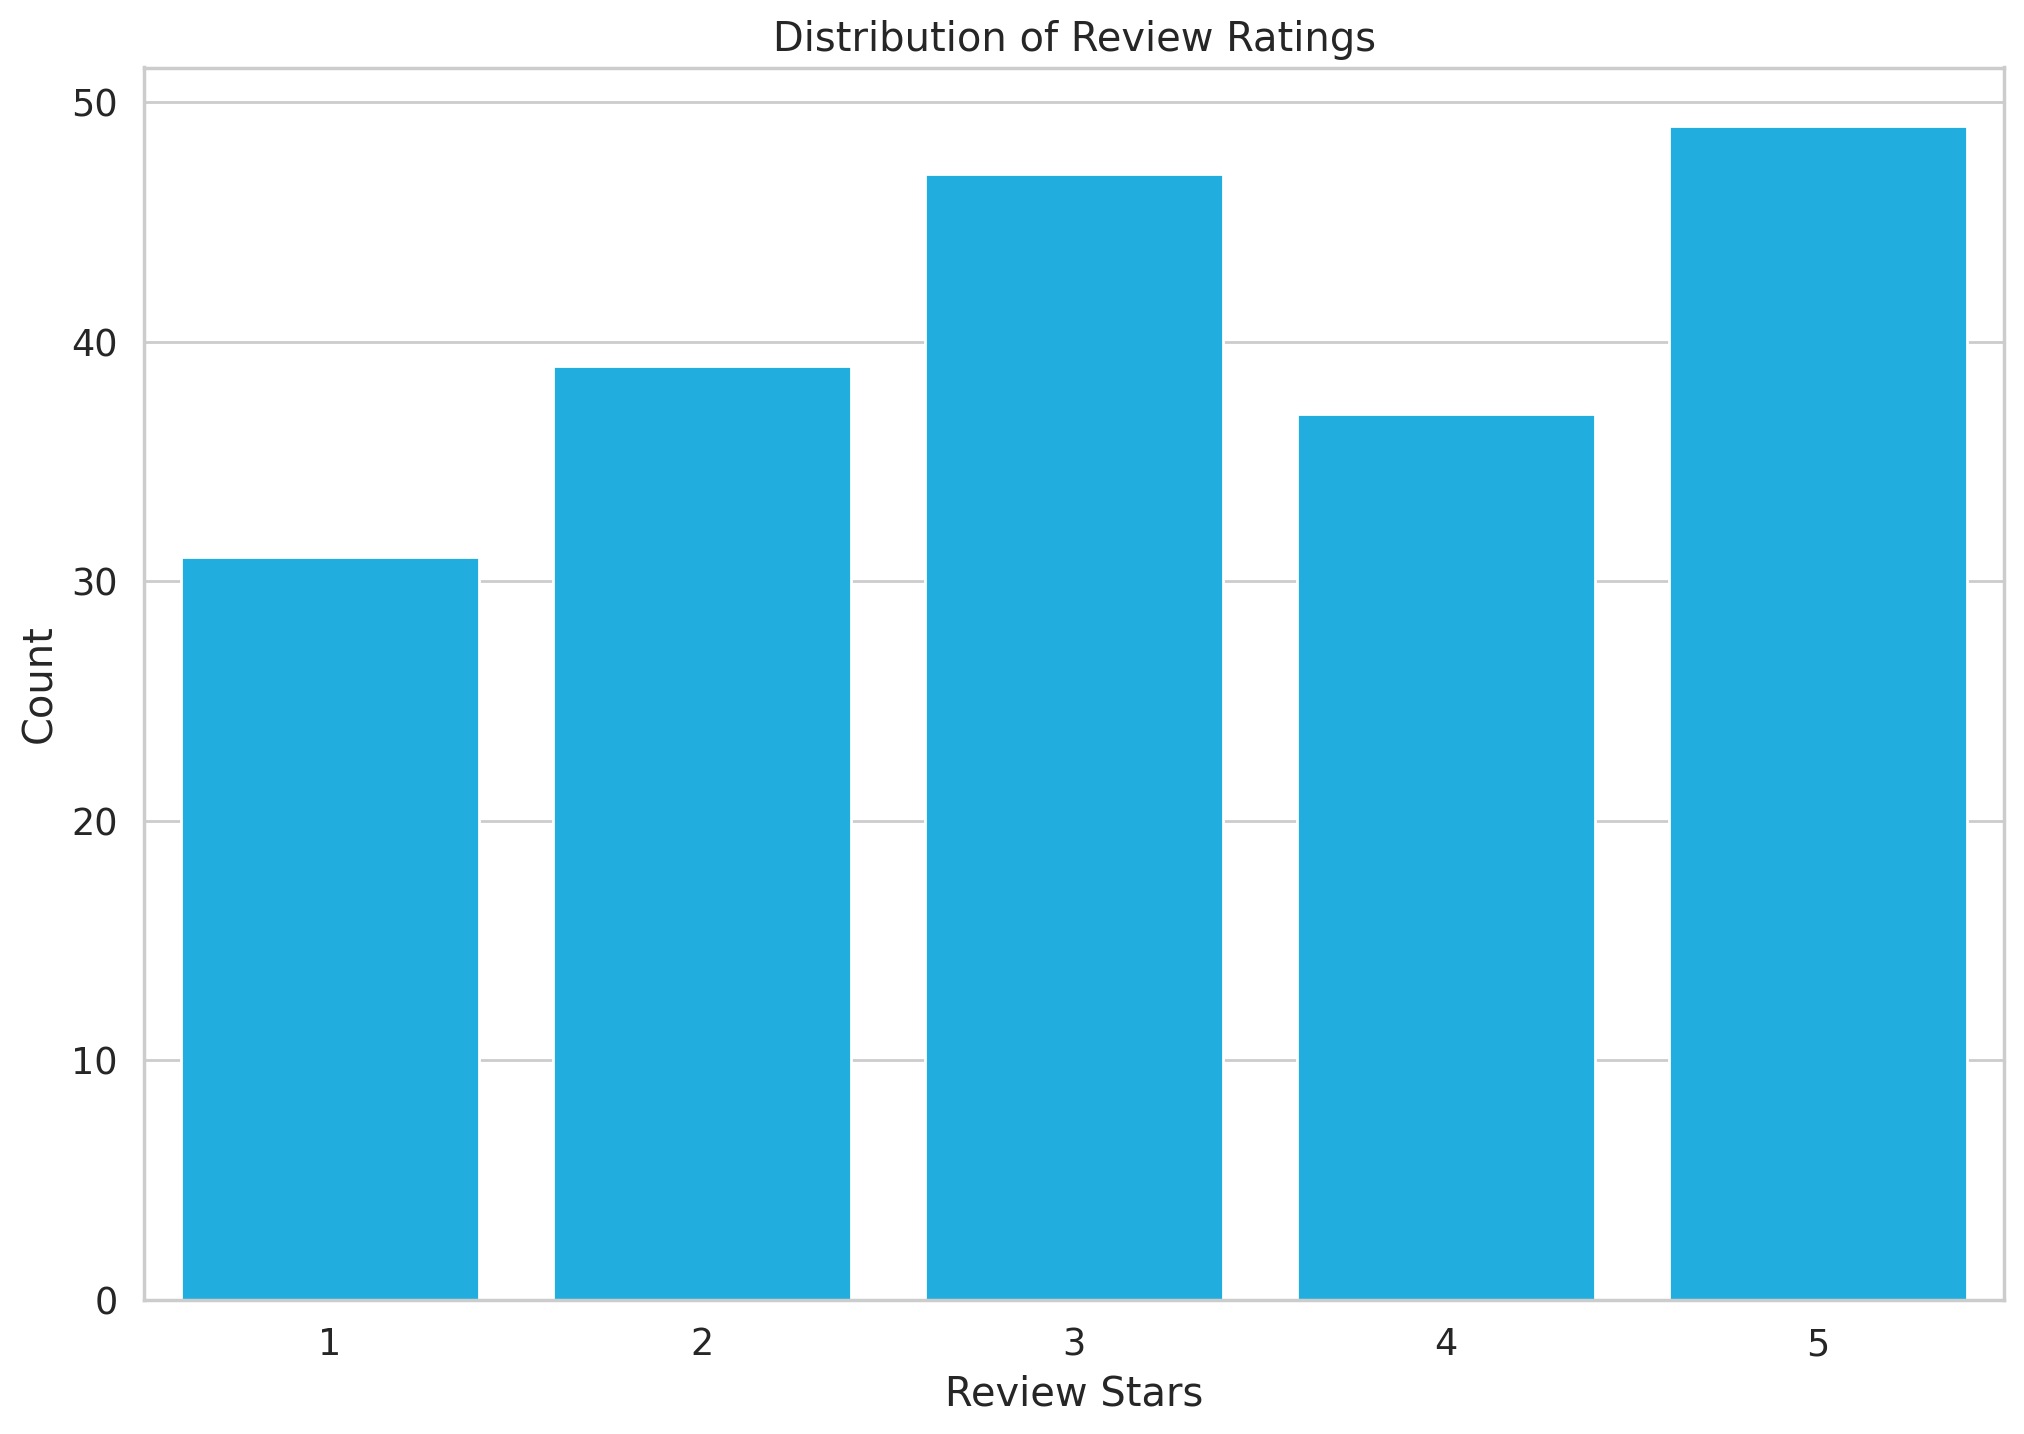

In [ ]:
class_names = ['negative', 'neutral', 'positive']
sns.countplot(x=df['stars'])  # Ensure `x=` is specified
plt.xlabel('Review Stars')
plt.ylabel('Count')
plt.title('Distribution of Review Ratings')
plt.show()


In [ ]:
# Set the model name
MODEL_NAME = 'bert-base-cased'

# Build a BERT based tokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
# Some of the common BERT tokens
print(tokenizer.sep_token, tokenizer.sep_token_id) # marker for ending of a sentence
print(tokenizer.cls_token, tokenizer.cls_token_id) # start of each sentence, so BERT knows we’re doing classification
print(tokenizer.pad_token, tokenizer.pad_token_id) # special token for padding
print(tokenizer.unk_token, tokenizer.unk_token_id) # tokens not found in training set

[SEP] 102
[CLS] 101
[PAD] 0
[UNK] 100


In [ ]:
# Store length of each review
token_lens = []
print(df.get('review'))
df['review'] = df['review'].astype(str).fillna('')  # Convert NaN to an empty string
token_lens = []
for txt in df.review:
    tokens = tokenizer.encode(txt, max_length=512, truncation=True)  # Add truncation=True
    token_lens.append(len(tokens))

# Iterate through the content slide
for txt in df.review:
    tokens = tokenizer.encode(txt, max_length=512)
    token_lens.append(len(tokens))

0      Terrible customer service. Î¾I came in at 9:30...
1                                                    nan
2      I see I'm not the only one giving 1 star. Only...
3      Well, it's McDonald's, so you know what the fo...
4                                                    nan
                             ...                        
198    Food is good but staff/service is HORRENDOUS. ...
199    An "A-OK" McDonalds... if you're leaving the S...
200    Not the best you'll find but not the worse eit...
201    Came here on a short re-feul from gambling all...
202                                                  nan
Name: review, Length: 203, dtype: object


Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Text(0.5, 0, 'Token count')

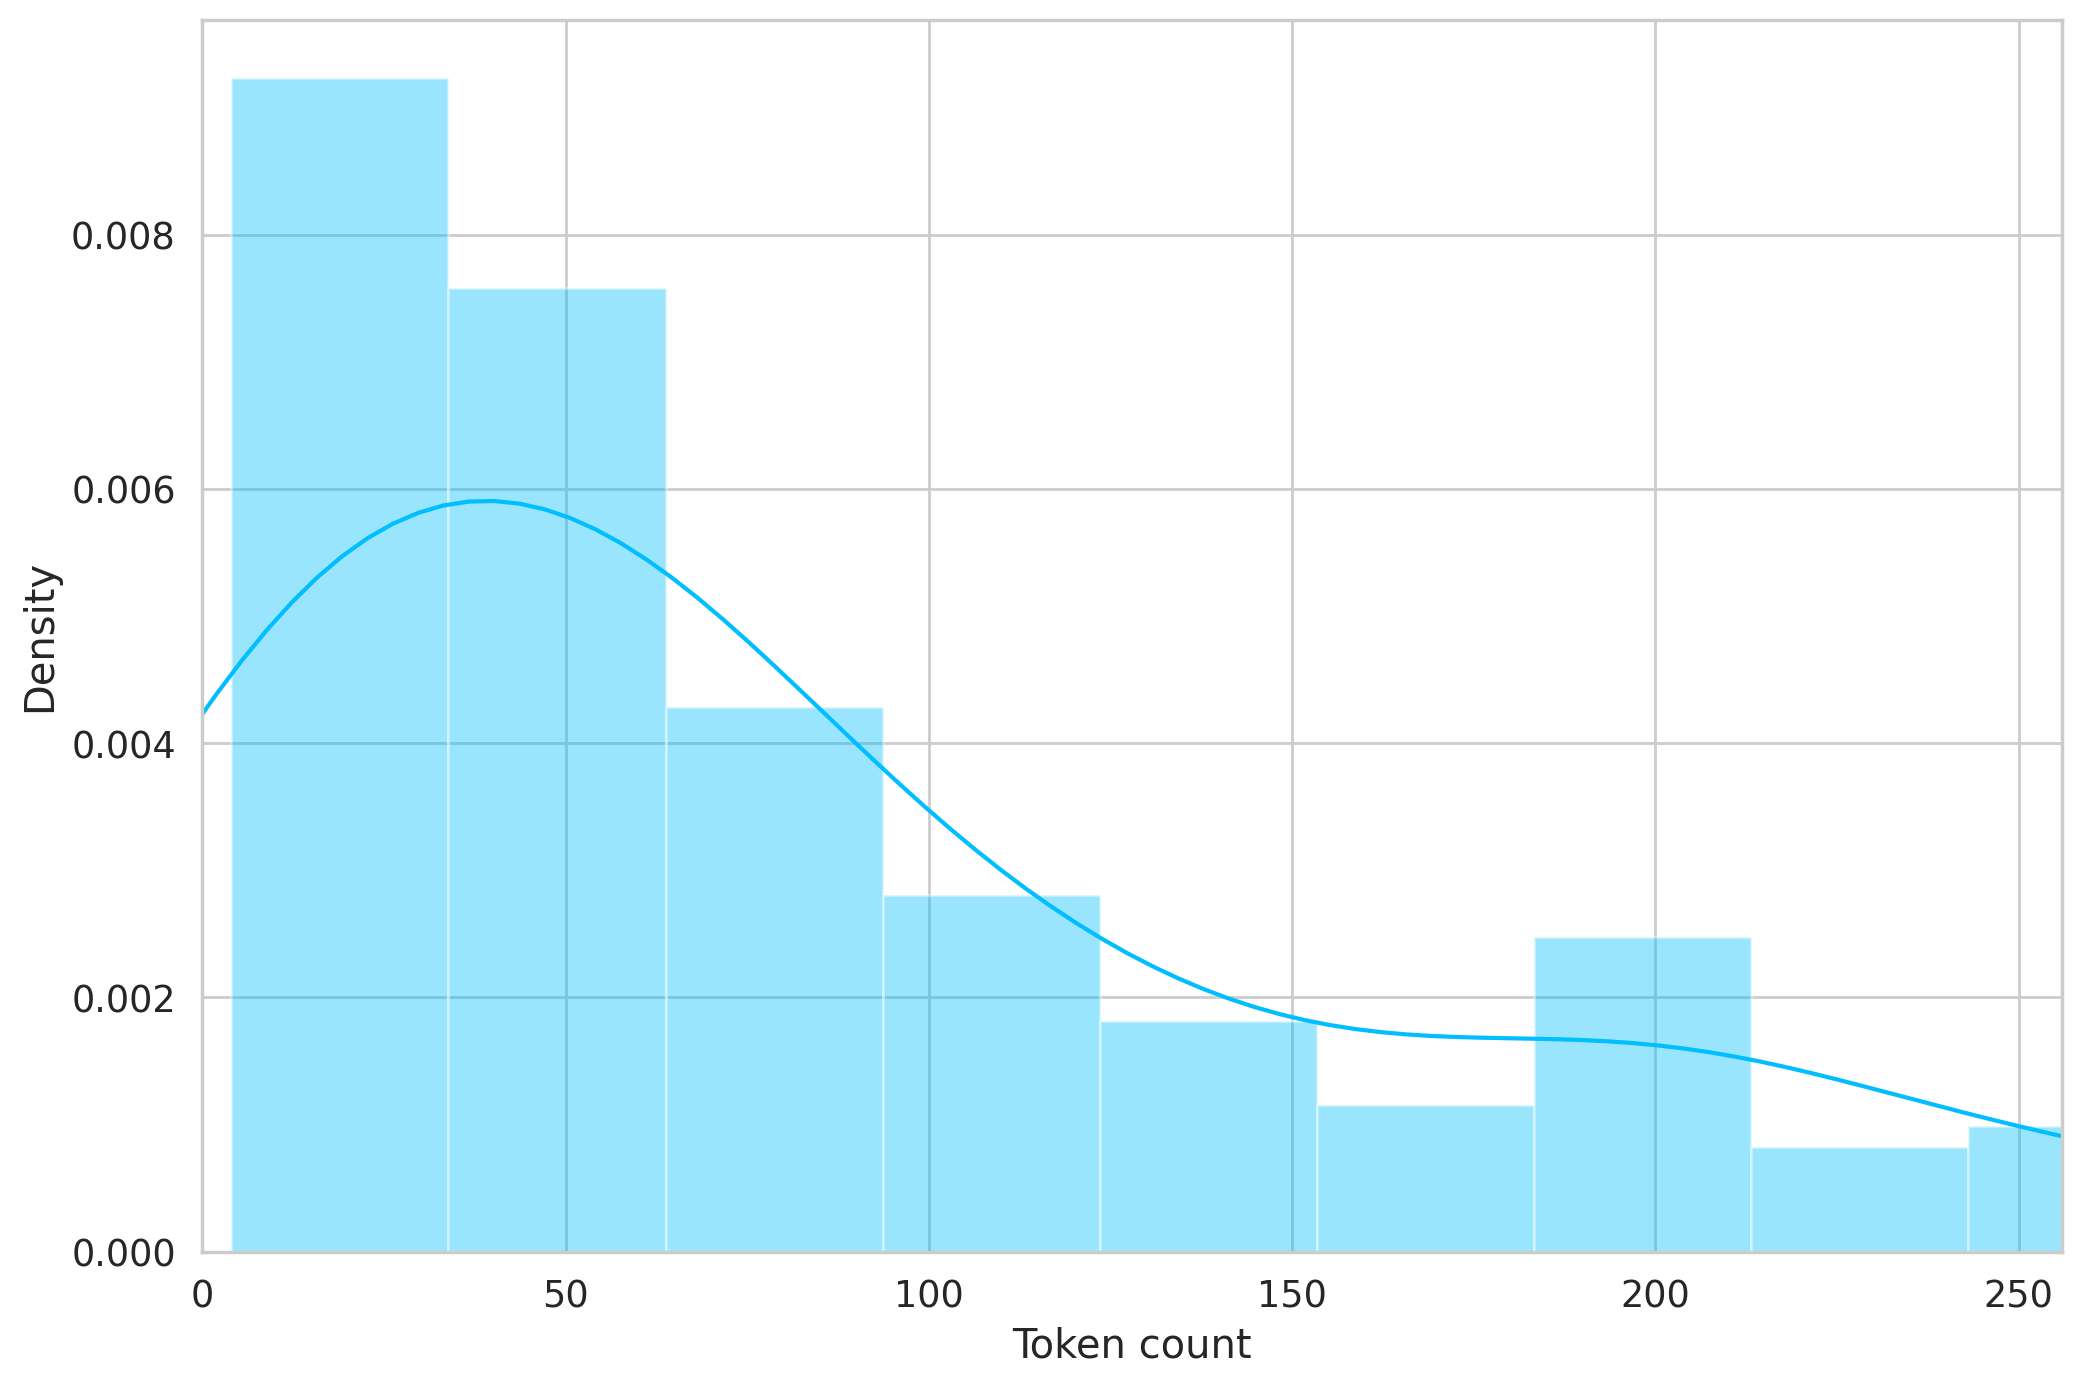

In [ ]:
sns.distplot(token_lens)
plt.xlim([0, 256]);
plt.xlabel('Token count')

In [ ]:
MAX_LEN = 160

In [ ]:
class GPReviewDataset(Dataset):
    # Constructor Function
    def __init__(self, reviews, targets, tokenizer, max_len):
        self.reviews = reviews
        self.targets = targets
        self.tokenizer = tokenizer
        self.max_len = max_len

    # Length magic method
    def __len__(self):
        return len(self.reviews)

    # get item magic method
    def __getitem__(self, item):
        review = str(self.reviews[item])
        target = self.targets[item]

        # Encoded format to be returned
        encoding = self.tokenizer.encode_plus(
            review,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            pad_to_max_length=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'review_text': review,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

print(df_train.shape, df_val.shape, df_test.shape)

(162, 6) (20, 6) (21, 6)


In [ ]:

def create_data_loader(df, tokenizer, max_len, batch_size):
    ds = GPReviewDataset(
        reviews=df.review.to_numpy(),
        targets=df.sentiment.to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        num_workers=0
    )

In [ ]:

# Create train, test and val data loaders
BATCH_SIZE = 16
train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [ ]:

# Examples
data = next(iter(train_data_loader))
print(data.keys())

print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])
torch.Size([16, 160])
torch.Size([16, 160])
torch.Size([16])


In [ ]:

# Load the basic BERT model
bert_model = BertModel.from_pretrained(MODEL_NAME)
data = next(iter(train_data_loader))
print(data.keys())

print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])
torch.Size([16, 160])
torch.Size([16, 160])
torch.Size([16])


In [ ]:
class SentimentClassifier(nn.Module):

    def __init__(self, n_classes):
        super(SentimentClassifier, self).__init__()
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pooled_output = output.pooler_output  # Extract tensor

        output = self.drop(pooled_output)  # Now it's a tensor
        return self.out(output)


In [ ]:
data = next(iter(train_data_loader))
print(type(data["input_ids"]))  # Should be torch.Tensor
print(type(data["attention_mask"]))  # Should be torch.Tensor
print(type(data["targets"]))  # Should be torch.Tensor


<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [ ]:

# Instantiate the model and move to classifier
model = SentimentClassifier(len(class_names))
model = model.to(device)

In [ ]:
print(bert_model.config.hidden_size)

768


In [ ]:
# Number of iterations
EPOCHS = 10

# Optimizer Adam
optimizer = AdamW(model.parameters(), lr=2e-5, correct_bias=False)

total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Set the loss function
loss_fn = nn.CrossEntropyLoss().to(device)

In [ ]:
# Function for a single training iteration
def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0

    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        # Backward prop
        loss.backward()

        # Gradient Descent
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    return correct_predictions.double() / n_examples, np.mean(losses)

In [ ]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()

    losses = []
    correct_predictions = 0

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            # Get model ouptuts
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)

            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses)
    print(df['sentiment'].unique())  # Should print: [0, 1, 2]


In [ ]:
history = defaultdict(list)
best_accuracy = 0

for epoch in range(EPOCHS):

    # Show details
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("-" * 10)
    train_acc, train_loss = train_epoch(
        model,
        train_data_loader,
        loss_fn,
        optimizer,
        device,
        scheduler,
        len(df_train)
    )

    print(f"Train loss {train_loss} accuracy {train_acc}")

    # Get model performance (accuracy and loss)
    val_acc, val_loss = eval_model(
        model,
        val_data_loader,
        loss_fn,
        device,
        len(df_val)
    )

    print(f"Val   loss {val_loss} accuracy {val_acc}")
    print()

    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)

    # If we beat prev performance
    if val_acc > best_accuracy:
        torch.save(model.state_dict(), 'best_model_state.bin')
        best_accuracy = val_acc

Epoch 1/10
----------
Train loss 0.9356766234744679 accuracy 0.6358024691358025
Val   loss 1.4083976745605469 accuracy 0.45

Epoch 2/10
----------
Train loss 0.8819095546549017 accuracy 0.6172839506172839
Val   loss 1.1188965737819672 accuracy 0.45

Epoch 3/10
----------
Train loss 0.6915423544970426 accuracy 0.691358024691358
Val   loss 1.245039939880371 accuracy 0.45

Epoch 4/10
----------
Train loss 0.5874562317674811 accuracy 0.7592592592592593
Val   loss 0.9676921963691711 accuracy 0.7

Epoch 5/10
----------
Train loss 0.48333616148341785 accuracy 0.8148148148148148
Val   loss 1.1073704361915588 accuracy 0.5

Epoch 6/10
----------
Train loss 0.4207886051047932 accuracy 0.9012345679012346
Val   loss 1.167473316192627 accuracy 0.55

Epoch 7/10
----------
Train loss 0.35425104200839996 accuracy 0.9012345679012346
Val   loss 1.2874408960342407 accuracy 0.4

Epoch 8/10
----------
Train loss 0.3157046098600734 accuracy 0.9074074074074074
Val   loss 1.304252177476883 accuracy 0.45

Epoch

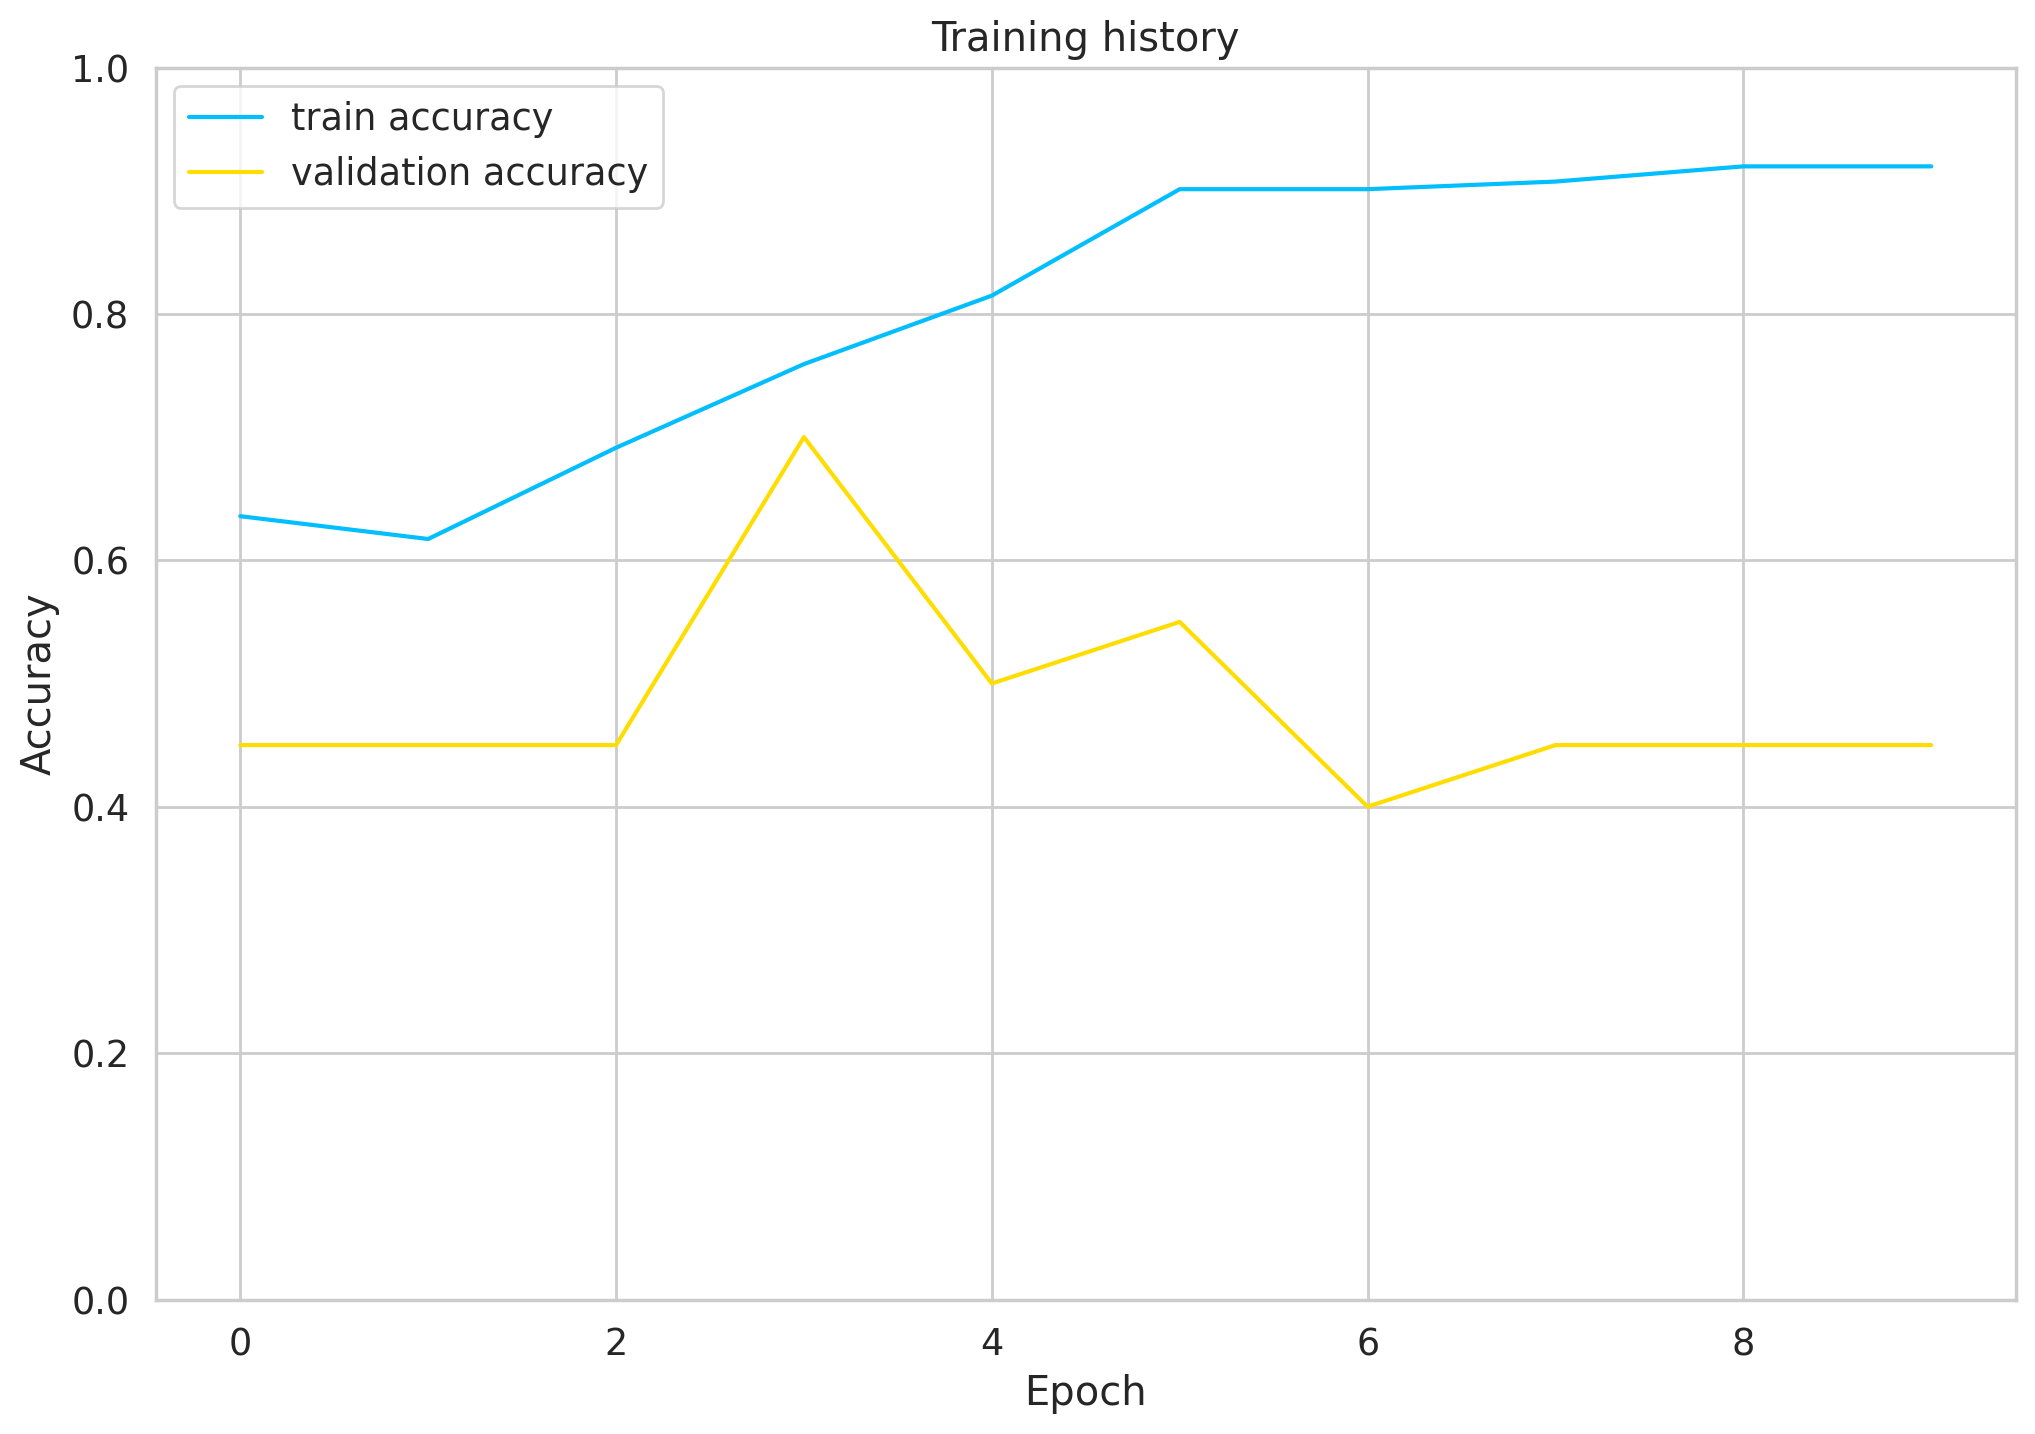

In [ ]:
# Plot training and validation accuracy
plt.plot(history['train_acc'], label='train accuracy')
plt.plot(history['val_acc'], label='validation accuracy')

# Graph chars
plt.title('Training history')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [ ]:

test_acc, _ = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(df_test)
)

test_acc.item()

0.47619047619047616

In [ ]:
def get_predictions(model, data_loader):
    model = model.eval()

    review_texts = []
    predictions = []
    prediction_probs = []
    real_values = []

    with torch.no_grad():
        for d in data_loader:
            texts = d["review_text"]
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            # Get outouts
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            _, preds = torch.max(outputs, dim=1)

            review_texts.extend(texts)
            predictions.extend(preds)
            prediction_probs.extend(outputs)
            real_values.extend(targets)

    predictions = torch.stack(predictions).cpu()
    prediction_probs = torch.stack(prediction_probs).cpu()
    real_values = torch.stack(real_values).cpu()

    return review_texts, predictions, prediction_probs, real_values

In [ ]:
y_review_texts, y_pred, y_pred_probs, y_test = get_predictions(
    model,
    test_data_loader
)

In [ ]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    negative       0.40      0.22      0.29         9
     neutral       0.67      0.40      0.50         5
    positive       0.46      0.86      0.60         7

    accuracy                           0.48        21
   macro avg       0.51      0.49      0.46        21
weighted avg       0.48      0.48      0.44        21



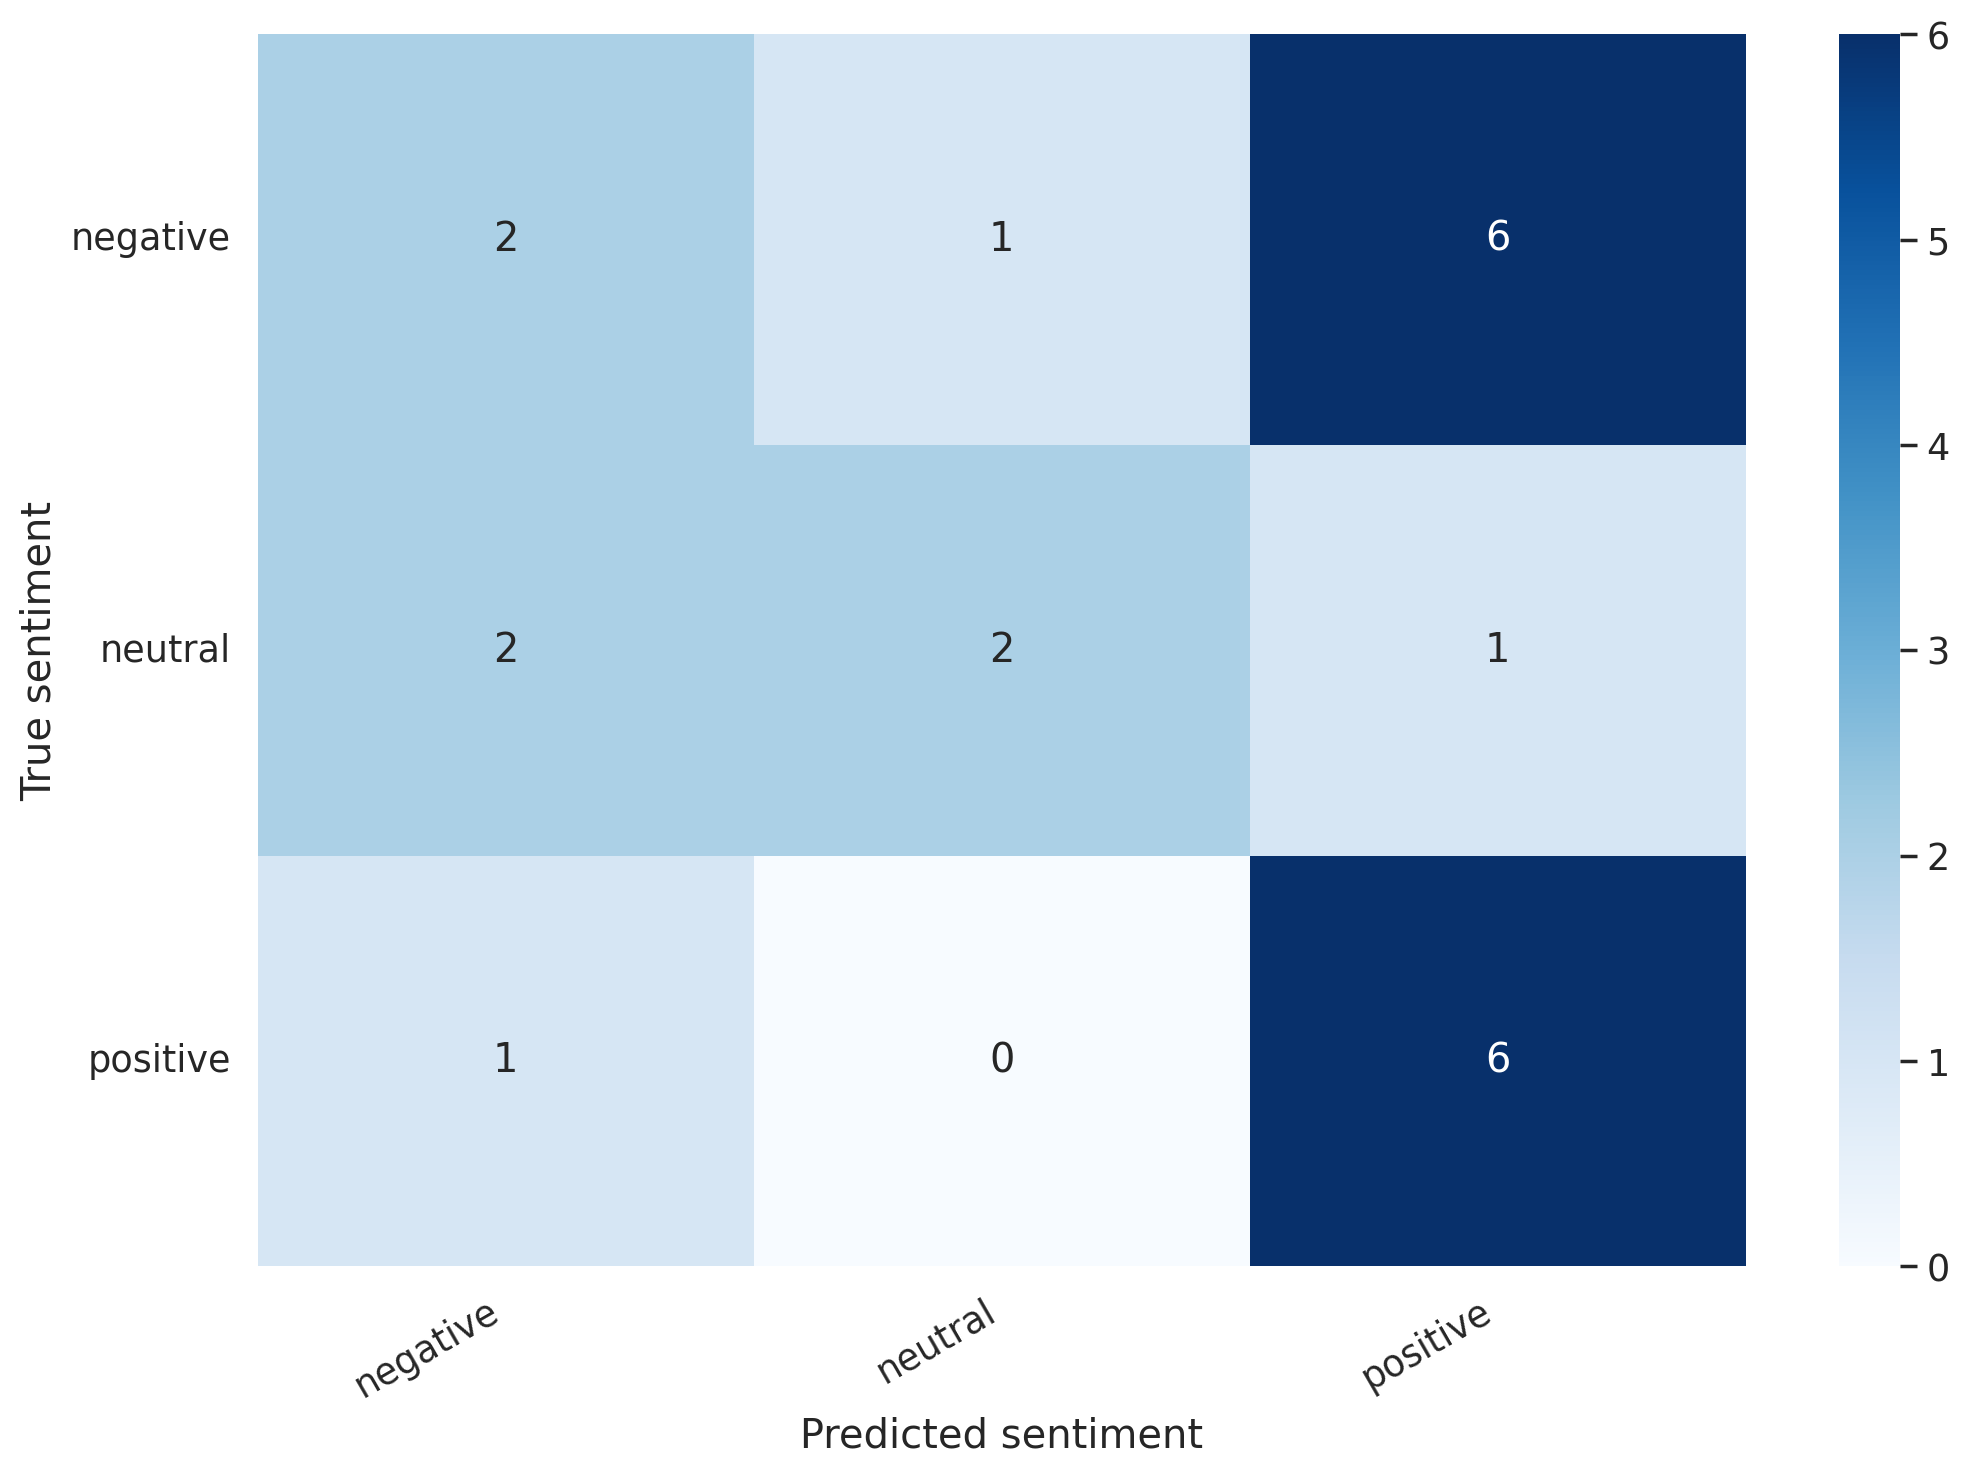

In [ ]:
def show_confusion_matrix(confusion_matrix):
    hmap = sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="Blues")
    hmap.yaxis.set_ticklabels(hmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    hmap.xaxis.set_ticklabels(hmap.xaxis.get_ticklabels(), rotation=30, ha='right')
    plt.ylabel('True sentiment')
    plt.xlabel('Predicted sentiment');

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
show_confusion_matrix(df_cm)

In [ ]:
model.eval()  # Set the model to evaluation mode
import torch.nn.functional as F
for review_text in df['review']:
    encoded_review = tokenizer.encode_plus(
        review_text,
        max_length=MAX_LEN,
        add_special_tokens=True,
        return_token_type_ids=False,
        pad_to_max_length=True,
        return_attention_mask=True,
        return_tensors='pt',
    )

    input_ids = encoded_review['input_ids'].to(device)
    attention_mask = encoded_review['attention_mask'].to(device)
    with torch.no_grad():
        output = model(input_ids, attention_mask)
        probs = F.softmax(output, dim=1)  # Convert logits to probabilities
        prediction = torch.argmax(probs, dim=1)  # Get class with highest probability

    print(f'Review text: {review_text}')
    print(f'Sentiment  : {class_names[prediction.item()]}')
    print("-" * 50)  # Separator for clarity


Review text: Terrible customer service. Î¾I came in at 9:30pm and stood in front of the register and no one bothered to say anything or help me for 5 minutes. Î¾There was no one else waiting for their food inside either, just outside at the window. Î¾ I left and went to Chickfila next door and was greeted before I was all the way inside. This McDonalds is also dirty, the floor was covered with dropped food. Obviously filled with surly and unhappy workers.
Sentiment  : negative
--------------------------------------------------
Review text: nan
Sentiment  : positive
--------------------------------------------------
Review text: I see I'm not the only one giving 1 star. Only because there is not a -25 Star!!! That's all I need to say!
Sentiment  : negative
--------------------------------------------------
Review text: Well, it's McDonald's, so you know what the food is. Î¾This review reflects solely on the poor service. Î¾I have been to this location countless times over the years. Î¾T